# Auto Ownership 
Validation to Household Travel Survey

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import os, sys
%matplotlib inline

os.chdir('..\..\..\..')

# from input_configuration import base_year
import toml
config = toml.load(os.path.join(os.getcwd(), 'configuration/input_configuration.toml'))

from IPython.display import display, HTML

if (sys.version_info < (3, 0)):
    HTML('''<script>
    code_show=true; 
    function code_toggle() {
     if (code_show){
     $('div.input').hide();
     } else {
     $('div.input').show();
     }
     code_show = !code_show
    } 
    $( document ).ready(code_toggle);
    </script>
    <form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')



In [2]:
working_dir = r'outputs/agg/dash'
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.2%}".format

In [3]:
def load_data(fname):
    """ open and join model and survey data """

    df_model = pd.read_csv(os.path.join(working_dir,fname+'.csv'))
    df_model['source'] = 'model'
    df_survey = pd.read_csv(os.path.join(working_dir,'survey',fname+'.csv'))
    df_survey['source'] = 'survey'
    df = pd.concat([df_model, df_survey], ignore_index=True)
    # df = df_model.append(df_survey)

    return df

## Regional Totals and Distribution

Text(0, 0.5, 'Household Vehicles Owned')

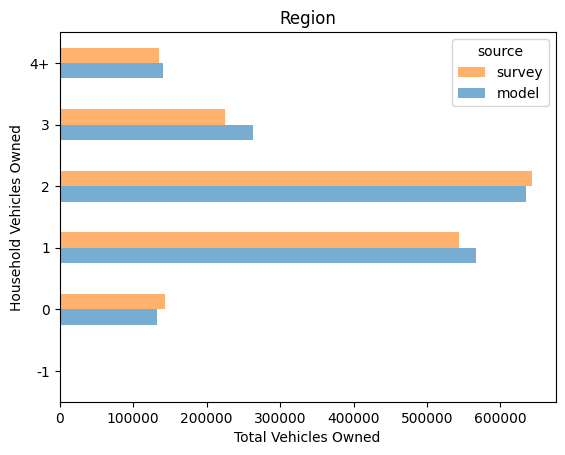

In [7]:
df = load_data('auto_ownership')
df.loc[df['hhvehs'] >= 4, 'hhvehs'] = '4+'
df = df.pivot_table(index='hhvehs', columns='source', aggfunc='sum', values='hhexpfac')
df.to_csv(os.path.join(working_dir, 'SC_2023_auto_ownership.csv'))
ax = df.plot(kind='barh', title='Region', legend='reverse', alpha=0.6)
ax.set_xlabel('Total Vehicles Owned')
ax.set_ylabel('Household Vehicles Owned')

Distribution of Vehicles Owned at Regional Scale

Text(0, 0.5, 'Household Vehicles Owned')

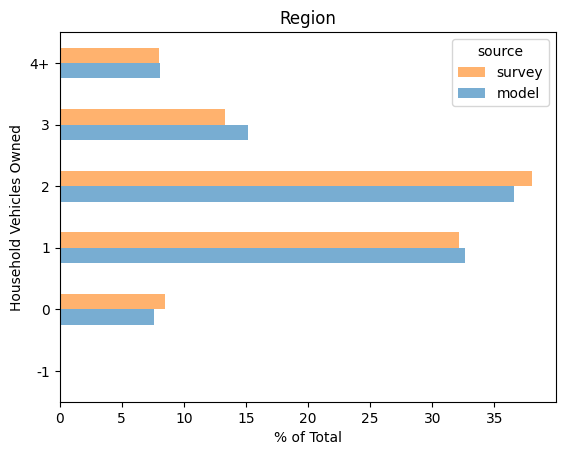

In [5]:
df['model'] = (df['model']/df['model'].sum()) * 100  
df['survey'] = (df['survey']/df['survey'].sum()) * 100  
df = df[['model', 'survey']]
ax = df.plot(kind='barh', title='Region', legend='reverse', alpha=0.6)
ax.set_xlabel("% of Total")
ax.set_ylabel('Household Vehicles Owned')

## By Income

In [8]:
df = load_data('auto_ownership')

# Define income groups
inc_bin=[-1,20000,40000,75000,9999999999999]
inc_bin_labels = ['0-$20k','$20-40k','$40-75k','>$75k']
df['income_bin'] = pd.cut(df['hhincome_thousands'], bins=inc_bin, labels=inc_bin_labels)

df.loc[df['hhvehs'] >= 3, 'hhvehs'] = '3+'
df['hhvehs'] = df['hhvehs'].astype(str)
df.rename(columns={'hhvehs': 'Household Vehicles Owned'}, inplace=True)
pd.pivot_table(df, index=['Household Vehicles Owned','source'], columns='income_bin', values='hhexpfac', aggfunc='sum')

income_bin                       0-$20k  $20-40k  $40-75k   >$75k
Household Vehicles Owned source                                  
-1                       model        0        0        0       0
                         survey       0        0        0     811
0                        model   44,861   24,058   22,695  40,211
                         survey  83,498   17,573   21,162  20,598
1                        model   59,909   77,802  144,753 283,483
                         survey 128,662   39,405  125,812 249,884
2                        model   23,404   39,143  104,734 467,238
                         survey 114,053   24,607  107,482 396,824
3+                       model    8,990   15,974   50,988 327,141
                         survey  45,833    5,406   59,494 249,690

In [ ]:
pd.options.display.float_format = "{:,.2%}".format
_df_model = pd.pivot_table(df[df['source'] == 'model'], index='Household Vehicles Owned', columns='hh_county', values='hhexpfac', aggfunc='sum')
_df_model = _df_model/_df_model.sum()  * 100
_df_survey = pd.pivot_table(df[df['source'] == 'survey'], index='Household Vehicles Owned', columns='hh_county', values='hhexpfac', aggfunc='sum')
_df_survey = _df_survey/_df_survey.sum()  * 100

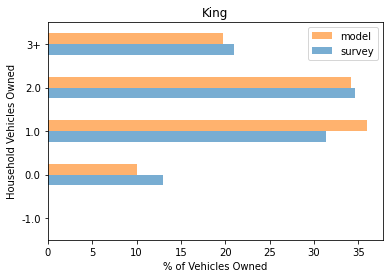

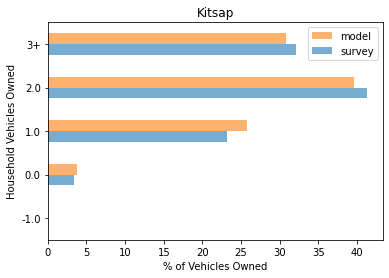

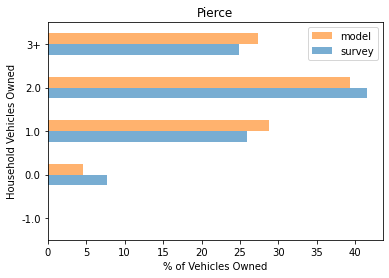

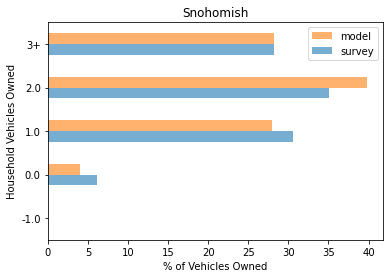

In [ ]:
for county in df['hh_county'].unique():
    if county != 'Outside Region':
        _df = pd.DataFrame([_df_survey[county],_df_model[county]]).T
        _df.columns = ['survey','model']
        ax = _df.plot(kind='barh', title=county, legend='reverse', alpha=0.6)
        ax.set_xlabel('% of Vehicles Owned')